In [1]:
from typing import Literal
from langgraph.types import Command
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import AIMessage

def agent_1(state: MessagesState) -> Command[Literal["agent_2"]]:
    messages = AIMessage(content="1번 에이전트 메시지입니다.")
    return Command(
        goto="agent_2",
        update={"messages": [messages]}
    )

def agent_2(state: MessagesState) -> Command[Literal[END]]:
    message = AIMessage(content="2번 에이전트 메시지입니다.")
    return Command(
        goto=END,
        update={"messages": [message]},
    )

graph_builder = StateGraph(MessagesState)
graph_builder.add_node("agent_1", agent_1)
graph_builder.add_node("agent_2", agent_2)

graph_builder.add_edge(START, "agent_1")

graph = graph_builder.compile()



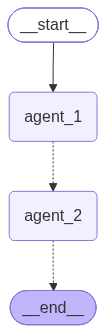

In [2]:
graph

In [3]:
for chunk in graph.stream({"messages" : []}, stream_mode="values"):
    print(chunk)

{'messages': []}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='8afcc5e6-35c7-4993-b112-0f41acdea9b8', tool_calls=[], invalid_tool_calls=[])]}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='8afcc5e6-35c7-4993-b112-0f41acdea9b8', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='2번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='c9d19d76-af15-45a4-b5fb-5ace0c9d198f', tool_calls=[], invalid_tool_calls=[])]}


In [4]:
from typing import Literal
from langgraph.types import Command
from langgraph.graph import StateGraph, MessagesState, START, END
from langchain_core.messages import AIMessage

class State(MessagesState):
    foo: str

def agent_1(state: State) -> Command[Literal["agent_2", "agent_3"]]:
    messages = AIMessage(content="1번 에이전트 메시지입니다.")
    if state["foo"] == "bar":
        return Command(
            goto="agent_3",
            update={"messages": [messages], "foo": "baz"}
        )
    return Command(
        goto="agent_2",
        update={"messages": [messages]}
    )

def agent_2(state: State):
    message = AIMessage(content="2번 에이전트 메시지입니다.")
    return Command(
        goto=END,
        update={"messages": [message]},
    )

def agent_3(state: State):
    message = AIMessage(content="3번 에이전트 메시지입니다.")
    return Command(
        goto=END,
        update={"messages": [message]},
    )

graph_builder = StateGraph(State)
graph_builder.add_node("agent_1", agent_1)
graph_builder.add_node("agent_2", agent_2)
graph_builder.add_node("agent_3", agent_3)

graph_builder.add_edge(START, "agent_1")

graph = graph_builder.compile()

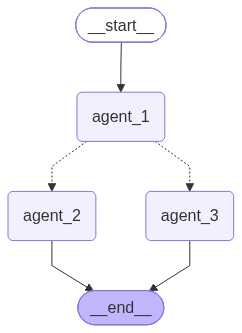

In [5]:
graph

In [7]:
for chunk in graph.stream({"messages" : [], "foo": "bar"}, stream_mode="values"):
    print(chunk)

{'messages': [], 'foo': 'bar'}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='b01e2188-be27-45b7-a1dd-e155014e1d2e', tool_calls=[], invalid_tool_calls=[])], 'foo': 'baz'}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='b01e2188-be27-45b7-a1dd-e155014e1d2e', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='3번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='fd7e9ae0-8a8e-42d0-874b-7adb35152c9a', tool_calls=[], invalid_tool_calls=[])], 'foo': 'baz'}


In [9]:
for chunk in graph.stream({"messages" : [], "foo": "baz"}, stream_mode="values"):
    print(chunk)

{'messages': [], 'foo': 'baz'}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='7beea438-1ead-4b45-8d5c-701e2eb5949e', tool_calls=[], invalid_tool_calls=[])], 'foo': 'baz'}
{'messages': [AIMessage(content='1번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='7beea438-1ead-4b45-8d5c-701e2eb5949e', tool_calls=[], invalid_tool_calls=[]), AIMessage(content='2번 에이전트 메시지입니다.', additional_kwargs={}, response_metadata={}, id='e0df6275-b778-4ec2-a989-b1e0ce673e96', tool_calls=[], invalid_tool_calls=[])], 'foo': 'baz'}
